# Redes Convolucionales desde Cero: Reconocimiento de Imágenes con Keras o PyTorch

## 2. Importación de librerías



In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## 3. Carga del Dataset

MNIST contiene 70.000 imágenes de dígitos escritos a mano (0–9). Cada imagen tiene tamaño 28x28 píxeles.

In [2]:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

print("Entrenamiento:", x_train.shape)
print("Prueba:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Entrenamiento: (60000, 28, 28)
Prueba: (10000, 28, 28)


## 4. Visualización de Imágenes

Visualizamos algunos ejemplos del conjunto de entrenamiento.

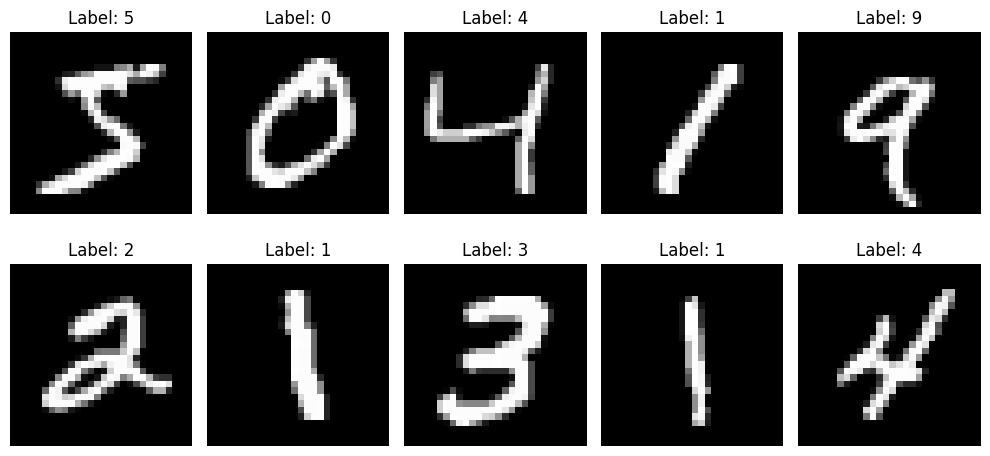

In [3]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## 5. Preprocesamiento

- Normalización de los valores de píxel entre 0 y 1.
- Adición de la dimensión del canal para que la CNN pueda procesar las imágenes.

In [4]:
x_train = x_train.reshape((60000, 28, 28, 1))
x_test = x_test.reshape((10000, 28, 28, 1))

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(x_train.shape)

(60000, 28, 28, 1)


## 6. Construcción de la CNN

Arquitectura:

Conv2D → MaxPooling → Conv2D → MaxPooling → Flatten → Dense → Output

### Explicación de componentes

- **Conv2D:** extrae características de la imagen.
- **ReLU:** introduce no linealidad.
- **MaxPooling:** reduce dimensionalidad.
- **Flatten:** transforma matrices en vectores.
- **Dense:** realiza la clasificación.
- **Softmax:** produce probabilidades para cada clase.


In [5]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Compilación del Modelo

- Optimizador: Adam
- Función de pérdida: Sparse Categorical Crossentropy
- Métrica: Accuracy


In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 8. Entrenamiento

Entrenamos durante 5 épocas utilizando el 20% del conjunto de entrenamiento para validación.

In [7]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 56s 35ms/step - accuracy: 0.9495 - loss: 0.1673 - val_accuracy: 0.9818 - val_loss: 0.0590
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9833 - loss: 0.0545 - val_accuracy: 0.9863 - val_loss: 0.0446
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 31ms/step - accuracy: 0.9884 - loss: 0.0368 - val_accuracy: 0.9867 - val_loss: 0.0429
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 29ms/step - accuracy: 0.9913 - loss: 0.0274 - val_accuracy: 0.9843 - val_loss: 0.0523
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 30ms/step - accuracy: 0.9928 - loss: 0.0220 - val_accuracy: 0.9864 - val_loss: 0.0457


## 9. Curva de Accuracy

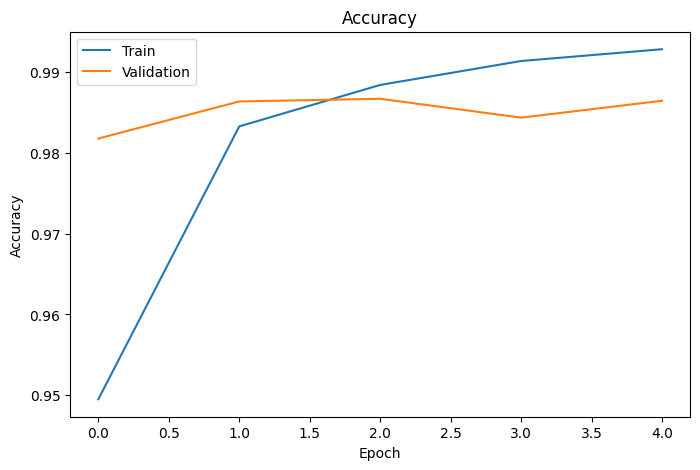

In [8]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## 10. Curva de Loss

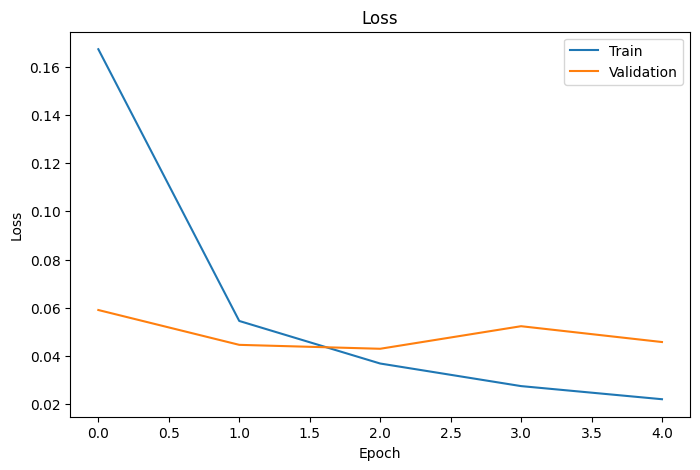

In [9]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 11. Evaluación del Modelo

In [10]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9862 - loss: 0.0420
Test Accuracy: 0.9861999750137329


## 12. Predicciones y Matriz de Confusión

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


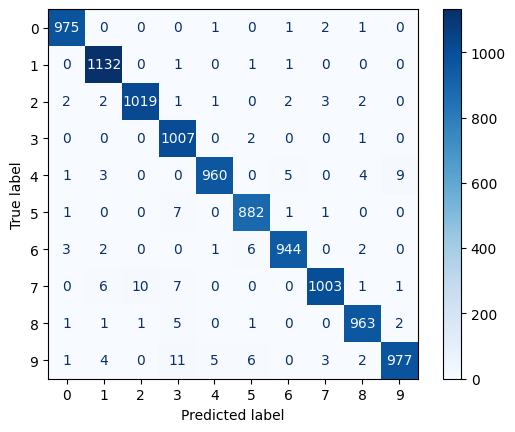

In [11]:
predictions = model.predict(x_test)
y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.show()

## 13. Predicciones Correctas

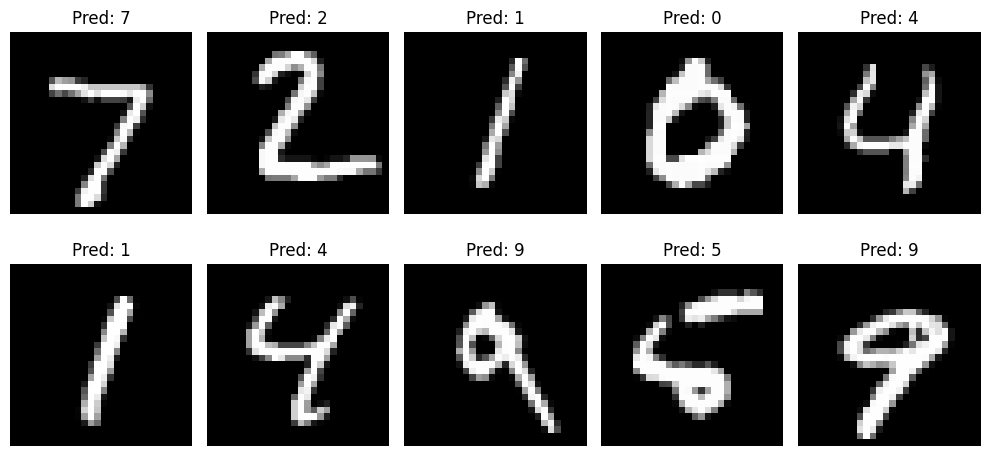

In [12]:
plt.figure(figsize=(10,5))

count = 0

for i in range(len(x_test)):
    if y_pred[i] == y_test[i]:
        count += 1
        plt.subplot(2,5,count)
        plt.imshow(x_test[i].reshape(28,28), cmap='gray')
        plt.title(f"Pred: {y_pred[i]}")
        plt.axis('off')

        if count == 10:
            break

plt.tight_layout()
plt.show()

## 14. Predicciones Incorrectas

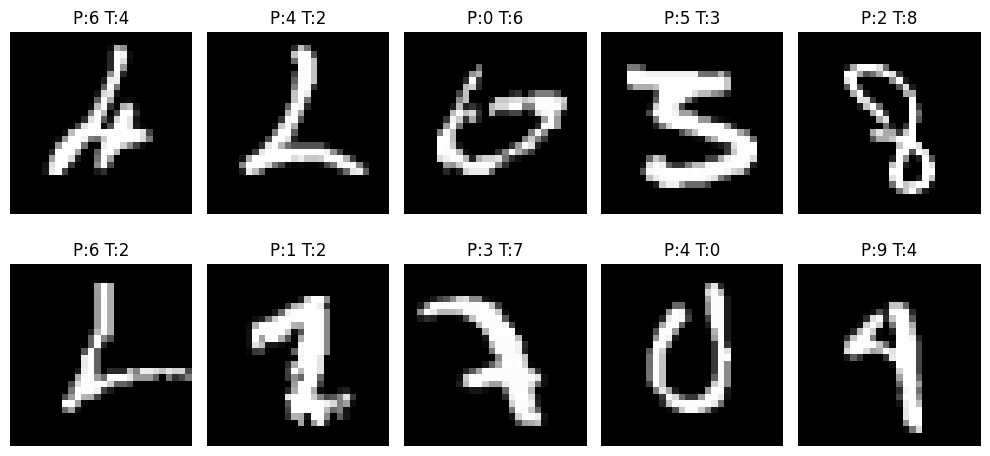

In [13]:
plt.figure(figsize=(10,5))

count = 0

for i in range(len(x_test)):
    if y_pred[i] != y_test[i]:
        count += 1
        plt.subplot(2,5,count)
        plt.imshow(x_test[i].reshape(28,28), cmap='gray')
        plt.title(f"P:{y_pred[i]} T:{y_test[i]}")
        plt.axis('off')

        if count == 10:
            break

plt.tight_layout()
plt.show()